# Preliminaries

## Dataset

In this set of exercises we will use the same dataset as from [week 3](week_3.ipynb). 


As before, we provide the data already curated in the following two files:

`RNA_expression_curated.csv`: [148 cell lines , 238 genes]

`drug_response_curated.csv`: [148 cell lines , YM155 drug]

The curated data can be read as `pandas` `DataFrame` in the following way:

In [1]:
import pandas as pd

gene_expression = pd.read_csv("./data/RNA_expression_curated.csv", sep=',', header=0, index_col=0)
drug_response = pd.read_csv("./data/drug_response_curated.csv", sep=',', header=0, index_col=0)

The goal of the exercises is to train support vector machine (SVM) and random forests classifiers on this dataset and explore and learn about their hyperparameters. 

## Tools

The `scikit-learn` library provides the required tools for support vector machines, as well as for random forest algorithms.

In [3]:
from sklearn import svm 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
#from sklearn.datasets.samples_generator import make_blobs, make_circles
from sklearn.datasets import make_blobs, make_circles
from sklearn.metrics import classification_report

Before proceeding, look up the documentation of the imported functions and read about their basic functionality. Below, we list some important parameters of SVMs and random forests that can be tuned during training.

#### Support Vector Machines (SVM)

`C`: error term.

`kernel`: similarity function ('linear', 'poly', 'sigmoid' or 'rbf')

`gamma`: kernel coef. for 'rbf', 'poly' and 'sigmoid' kernels. It can be thought of as the ‘spread’ of the kernel and therefore the decision region.

`degree`: degree for the 'poly' kernel.

`coef0`: independt term in the 'poly' and 'sigmoid' kernels


#### Random Forests

`n_estimators`: number of trees in our random forest.

`max_depth`: maximum number of levels in each decision tree

`max_features`: maximum number of features to consider per split in an individual tree.

`min_sample_leaf`: minimum number of data points per leaf node

`min_samples_split`: minimum number of data points placed in a node before the node is split

`oob_score`: the out-of-bag (OOB) error is the average error for each observation calculated using predictions from the trees that do not contain that observation in their respective bootstrap sample. Set this parameter to true.

`bootstrap`: method for sampling data points (with or without replacement). Set this parameter to true.

`criterion`: function used to measure the quality of the split (e.g. 'entropy' or 'gini')

# Exercises

## Support vector machines

The  `make_blobs` and `make_circles` functions can be used to generate linearly and not linearly separable toy datasets. 

In [4]:
# data generation: linearly separable
X, Y = make_blobs(n_samples=200, centers=2, n_features=2, random_state=1234)
X = pd.DataFrame(X, columns=['x1', 'x2'])

# splitting data into training and test set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33, random_state=333)

The following code illustrates how to train a linear SVM classifier and plot the data points, the separating hyperplane, the support vectors and the margins that pass through them (considering the training data)

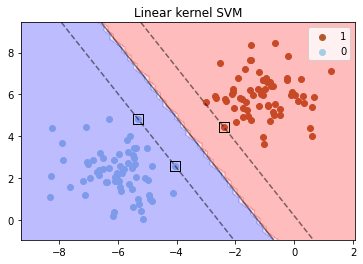

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# build the model
model = svm.SVC(kernel='linear', random_state=33)
model.fit(X_train, Y_train)

# create plot
fig, ax = plt.subplots()

# get colors from qualitative colormap 'Paired'
cmap = plt.cm.get_cmap('Paired')

# plot data points
ax.scatter(X_train.iloc[Y_train == 1, 0], X_train.iloc[Y_train == 1, 1],
           c=[cmap(11)], label='1')
ax.scatter(X_train.iloc[Y_train == 0, 0], X_train.iloc[Y_train == 0, 1],
           c=[cmap(0)], label='0')
ax.legend(loc='best')

# plot the decision function
# create grid to evaluate model
x1_min, x1_max = X_train.iloc[:, 0].min() - 1, X_train.iloc[:, 0].max() + 1
x2_min, x2_max = X_train.iloc[:, 1].min() - 1, X_train.iloc[:, 1].max() + 1

XX, YY = np.meshgrid(np.arange(x1_min, x1_max, .2),
                     np.arange(x2_min, x2_max, .2))

xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model.decision_function(xy).reshape(XX.shape)

# plot decision boundary and margins
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])

# Establish the class for each point in the contour
Z = model.predict(xy).reshape(XX.shape)

# Visualization of the contour
ax.contourf(XX, YY, Z, cmap='bwr', alpha=0.3)

# plot support vectors, whose are responsible for building the margins
ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100,
           linewidth=1, facecolors='none', edgecolors='k', marker='s')

ax.axis([x1_min, x1_max, x2_min, x2_max])
plt.axis('tight')
plt.title('Linear kernel SVM')
plt.show()

Train a radial basis function (RBF) SVM classifier with `gamma=0.5` and plot the results in the same way.

In [6]:
# data generation: not linearly separable
X, Y = make_circles(n_samples=200, noise=0.05, random_state=1234)
X = pd.DataFrame(X, columns=['x1', 'x2'])

# splitting data into training and test set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33, random_state=333)

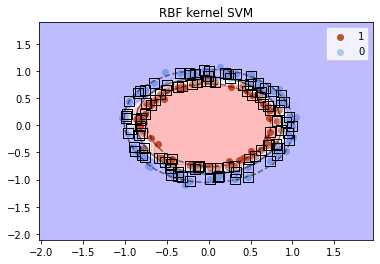

In [9]:
# build the model
model = svm.SVC(kernel='rbf', random_state=33)
model.fit(X_train, Y_train)

# create plot
fig, ax = plt.subplots()

# get colors from qualitative colormap 'Paired'
cmap = plt.cm.get_cmap('Paired')

# plot data points
ax.scatter(X_train.iloc[Y_train == 1, 0], X_train.iloc[Y_train == 1, 1],
           c=[cmap(11)], label='1')
ax.scatter(X_train.iloc[Y_train == 0, 0], X_train.iloc[Y_train == 0, 1],
           c=[cmap(0)], label='0')
ax.legend(loc='best')

# plot the decision function
# create grid to evaluate model
x1_min, x1_max = X_train.iloc[:, 0].min() - 1, X_train.iloc[:, 0].max() + 1
x2_min, x2_max = X_train.iloc[:, 1].min() - 1, X_train.iloc[:, 1].max() + 1

XX, YY = np.meshgrid(np.arange(x1_min, x1_max, .2),
                     np.arange(x2_min, x2_max, .2))

xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model.decision_function(xy).reshape(XX.shape)

# plot decision boundary and margins
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])

# Establish the class for each point in the contour
Z = model.predict(xy).reshape(XX.shape)

# Visualization of the contour
ax.contourf(XX, YY, Z, cmap='bwr', alpha=0.3)

# plot support vectors, whose are responsible for building the margins
ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100,
           linewidth=1, facecolors='none', edgecolors='k', marker='s')

ax.axis([x1_min, x1_max, x2_min, x2_max])
plt.axis('tight')
plt.title('RBF kernel SVM')
plt.show()

<p><font color='#770a0a'>When should a RBF kernel be used over a linear kernel? Motivate your answer.</font></p>

<p><font color='#770a0a'>Do we need to normalize the data before using a kernel function? Motivate your answer.
</font></p>

### Q1
A linear kernel can be used when data is already seperable in its feature space. No transformation is needed for clear seperation. The RBF kernel implicitly maps data into an infinite-dimensional space, allowing for nonlinear decision boundaries. So an RBF kernel should be chosen when data becomes more complex and linearly non-seperable in its own feature space. However, when applying an RBF when not necessary, it leads to overfitting and unnecessary computional power

### Q2
Yes. Kernels rely on distance-based metrics, for example euclidian distances are determined. If there are large distances compared to small distances, the large distance will dominate and the small distances "disregarded", causing biased results.

In [24]:

data_DR = drug_response
data_GE = gene_expression
X_train, X_test, y_train, y_test = train_test_split(data_GE, data_DR['YM155'])
import numpy as np
import pandas as pd
from scipy import stats


print("X shape:", data_GE.shape)               
print("DR shape:", data_DR.shape)              

y = data_DR['YM155']
print("y dtype:", y.dtype)
print("y head:\n", y.head())

# expects labels rather than continuous values, therefore z scores to make it binary
z= (y - y.mean())/y.std()

labels = pd.Series(index=y.index, dtype=int)
labels[z<0] = 1
labels[z>=0] = 0
print("Label counts:\n", labels.value_counts())
X_train, X_test, y_train, y_test = train_test_split(data_GE, labels, stratify = labels)


X shape: (148, 238)
DR shape: (148, 1)
y dtype: float64
y head:
 949176     0.42
749714    -4.31
749709    -4.80
1660034   -0.88
1240123    1.82
Name: YM155, dtype: float64
Label counts:
 1    85
0    63
dtype: int64


              precision    recall  f1-score   support

           0       0.90      0.56      0.69        16
           1       0.74      0.95      0.83        21

    accuracy                           0.78        37
   macro avg       0.82      0.76      0.76        37
weighted avg       0.81      0.78      0.77        37

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END svc__C=0.1, svc__gamma=1, svc__kernel=rbf;, score=0.565 total time=   0.0s
[CV 2/5] END svc__C=0.1, svc__gamma=1, svc__kernel=rbf;, score=0.545 total time=   0.0s
[CV 3/5] END svc__C=0.1, svc__gamma=1, svc__kernel=rbf;, score=0.591 total time=   0.0s
[CV 4/5] END svc__C=0.1, svc__gamma=1, svc__kernel=rbf;, score=0.591 total time=   0.0s
[CV 5/5] END svc__C=0.1, svc__gamma=1, svc__kernel=rbf;, score=0.591 total time=   0.0s
[CV 1/5] END svc__C=0.1, svc__gamma=0.1, svc__kernel=rbf;, score=0.565 total time=   0.0s
[CV 2/5] END svc__C=0.1, svc__gamma=0.1, svc__kernel=rbf;, score=0.545 total time

[CV 4/5] END svc__C=100, svc__gamma=0.0001, svc__kernel=rbf;, score=0.636 total time=   0.0s
[CV 5/5] END svc__C=100, svc__gamma=0.0001, svc__kernel=rbf;, score=0.545 total time=   0.0s
[CV 1/5] END svc__C=1000, svc__gamma=1, svc__kernel=rbf;, score=0.565 total time=   0.0s
[CV 2/5] END svc__C=1000, svc__gamma=1, svc__kernel=rbf;, score=0.545 total time=   0.0s
[CV 3/5] END svc__C=1000, svc__gamma=1, svc__kernel=rbf;, score=0.591 total time=   0.0s
[CV 4/5] END svc__C=1000, svc__gamma=1, svc__kernel=rbf;, score=0.591 total time=   0.0s
[CV 5/5] END svc__C=1000, svc__gamma=1, svc__kernel=rbf;, score=0.591 total time=   0.0s
[CV 1/5] END svc__C=1000, svc__gamma=0.1, svc__kernel=rbf;, score=0.565 total time=   0.0s
[CV 2/5] END svc__C=1000, svc__gamma=0.1, svc__kernel=rbf;, score=0.545 total time=   0.0s
[CV 3/5] END svc__C=1000, svc__gamma=0.1, svc__kernel=rbf;, score=0.591 total time=   0.0s
[CV 4/5] END svc__C=1000, svc__gamma=0.1, svc__kernel=rbf;, score=0.591 total time=   0.0s
[CV 5

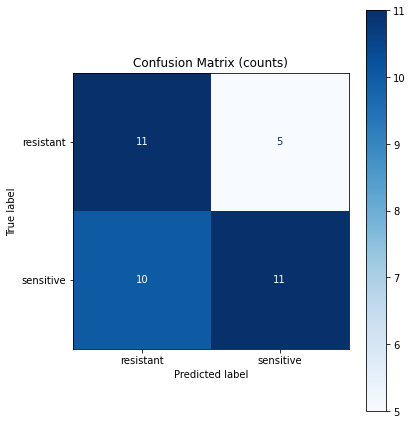

In [33]:
model = svm.SVC() 
model.fit(X_train, y_train) 

predictions = model.predict(X_test) 
print(classification_report(y_test, predictions))

from sklearn.model_selection import GridSearchCV 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import classification_report, precision_score, confusion_matrix, ConfusionMatrixDisplay

pipe = Pipeline([('scaler', StandardScaler()), ('svc', svm.SVC())])

param_grid = {'svc__C': [0.1, 1, 10, 100, 1000], 
              'svc__gamma': [1, 0.1, 0.01, 0.001, 0.0001], 
              'svc__kernel': ['rbf']} 

grid = GridSearchCV(pipe, param_grid, refit = True, verbose = 3) 
 
grid.fit(X_train, y_train)


print("best params: ", grid.best_params_)  
print("best estimator: ", grid.best_estimator_)

grid_predictions = grid.predict(X_test) 

print(classification_report(y_test, grid_predictions))

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
labels_names = ['resistant', 'sensitive']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_names)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
ax.set_title("Confusion Matrix (counts)")
plt.tight_layout()
plt.show()


## Predicting drug response on cell lines from gene expression data with SVMs

Explore the hyper-parameter space of an SVM classifier with cross-validation for the Genomics of Drug Sensitivity in Cancer (GDSC) dataset. The`GridSearchCV` function can be used to specify a grid of parameter values with the `param_grid` parameter.

Calculate the precision of your predictions, and compare your calculations with the results of `classification_report`, which displays many classification metrics.


## Random forests

Follow the same steps as for SVM. Compare the two algorithms and report which one has better performance.

The random forests classifiers allows to perform feature selection. Evaluate the importance of features extracting the top 50 informative features. A bar plot (`plt.bar()`) can be a useful tool to visualize this. 


## Biomedical applications

Driven by technological advances, there has recently been a dramatic increase in availability of biomedical data. Machine learning approaches are well suited to take advantage of this data and have been widely applied to many areas of biology. 

Example of these applications are genome annotation, biomarker identification, systems biology, genome data analysis, protein  function  prediction, protein  structure prediction, protein localization prediction, identification of protein interactions and drug discovery.

SVM and RF methods are among the most popular machine learning methods applied in bioinformatics or computational biology.

Perform a literature search and find a biomedical study in which SVM or RF is applied to obtain certain insights. <p><font color='#770a0a'>Explain the motivation behind using that specific algorithm in the study.
</font></p>

# Biomedical Applications

#### Paper: 
Gene Expression Data Classification using Support Vector Machine and Mutual Information-based Gene Selection 

#### Summary: 
The paper proposes a classification framework that combines Mutual Information based gene selection with a Support Vector Machine classifier. MI is used to rank genes by their non‑linear dependence on the class label, and the top ranking genes are retained as an informative subset,  reducing the high dimensional feature space. The selected genes train an SVM model, various kernels are evaluated, and the linear kernel consistently yields the highest accuracy.

Two public cancer datasets are used for validation:a colon‑cancer set and a lymphoma set.For the colon data, the linear‑kernel SVM reaches 67.74 % mean accuracy with only three informative genes, outperforming k‑NN (44.5 %) and ANN (50.9 %). For the lymphoma data, the linear‑kernel SVM attains 97.77 % mean accuracy using four genes, again surpassing the other methods.  

The results demonstrate that, first of all MI effectively isolates a small, highly discriminative gene subset. Secondly the SVM handles the resulting low‑dimensional data robustly, and finally the linear kernel provides superior performance with minimal computational cost. The authors conclude that the SVM‑MI approach offers a practical tool for clinical diagnosis of cancer from micro array profiles.

#### Motivation: 
In this paper the authors needed a method that could handle the extremely high dimensional gene‑expression data, and also discard noisy or irrelevant genes, and to produce a robust classifier even when only a few training samples are available.  

1. Gene selection motivation: Microarray data contain thousands of genes but most of them carry little information about the disease class so they act as noise and increase training time. Mutual Information measures the non‑linear statistical dependence between each gene and the class label, and can be computed efficiently from histograms. By ranking genes with MI the authors could isolate a very small subset of informative genes that most strongly correlate with the class distinction, dramatically reducing dimensionality and improving classifier training speed and accuracy.  

2. Classifier motivation: SVMs are suited to high dimensional, small sample problems because they rely on a sparse set of support vectors, can handle both linear and non linear decision boundaries through kernels, and SVMs have strong generalisation guarantees. The authors evaluated several kernels and found that the linear kernel consistently gave the highest classification accuracy while keeping the model simple and computationally cheap.


Combining MI‑based gene selection with an SVM therefore addresses the two main challenges of microarray classification: it first prunes the feature space to the most important genes, and then applies a classifier that can learn accurate decision boundaries from the reduced, noise free data. This pipeline achieved higher accuracy than k‑NN or ANN baselines on both colon cancer and lymphoma datasets, showing its practical value for cancer diagnosis.
